
## Project: Predicting article retweets and likes based on the title using Machine Learning

# Analysis

## Data Exploration

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
from time import time
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Import any additional functionality you may need here
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
import re

from sklearn.model_selection import cross_val_score
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import GradientBoostingClassifier
sns.set_style('whitegrid')
sns.set_palette('coolwarm')

import nltk
import ssl
from nltk.corpus import stopwords
nltk.download('stopwords')
print('Success')

Success


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Load the FreeCodeCamp Twitter statistics and Medium statistics.
# Read imported data
title_stat = pd.read_json("dataset-tweets-final.json")
print("Title statistic data read successfully!")

Title statistic data read successfully!


In [ ]:
# clean the title
def clean_text(text):
    # remove wrong convertion characters from title
    text = text.map(lambda x: re.sub(r'\\x[00-ff]{2}','',str(x)))
    text = text.str.strip()
    text = text.map(lambda x: re.sub('b"','',str(x)))
    return text

In [ ]:
#remove duplicates
title_stat = title_stat.drop_duplicates(subset=['text'], keep=False)
# Remove some columns to print
title_stat = title_stat.drop(['id', 'created_at', 'url'], axis=1)
#
title_stat['text'] = clean_text(title_stat['text'])
# calculate length of the titles
title_stat['text_lenght'] = title_stat['text'].str.len()
# reorder the columns
title_stat = title_stat[title_stat.columns[[4, 0, 3, 2, 5, 1]]]
# rename the columns
temp = title_stat.rename(index=str, columns={"favorite_count": "Likes (Twitter)", "medium_categories": "Categories (Medium)", "medium_claps": "Claps (Medium)", "retweet_count": "Retweet (Twitter)", "text": "Title (Twitter)", "text_lenght": "Title Length"})
title_stat = title_stat.rename(index=str, columns={"favorite_count": "Likes", "medium_categories": "Categories", "medium_claps": "Claps", "retweet_count": "Retweet", "text": "Title", "text_lenght": "Title Length"})
# limit the total number of lines to print
temp.head()

,Categories (Medium),Retweet (Twitter),Claps (Medium),Title (Twitter),Title Length,Likes (Twitter)
0,"[JavaScript, HTML, Web Development, Tutorial, ...",5,177,How to use JSON padding (and other options) to...,76,10
1,"[React, Tech, Functional Programming, Programm...",7,61,How to build GitHub search functionality in Re...,90,19
2,"[iOS, Software Development, Programming, Web D...",6,54,How to read and write Mindful Minutes from iOS...,81,11
3,"[Freelancing, Tech, Web Development, Web Desig...",9,139,"How to make more money on Upwork, by @jpmorris",46,39
4,"[CSS, Games, Tech, Programming, React]",14,342,Let's build a fun little game: Learn advanced ...,116,62


### Exploratory Visualization

This section will explore the data visualization of the existing dataset and analyze the possible metrics that will be used to understand the solution. We will identify the relationship between each one of the features with the overall performance of the article. Within the following steps we will discuss:

* General statistic overview of the dataset
* Distribution of retweets, claps and favorites
* Relation of the title length with the performance of the article
* Relation of the article's categories with the performance of the article
* Relation of the article's words with the performance of the article
* Try to identify the relation between the features

#### Overall Statistics

We will analyze here the high-level statistics of the articles. Try to understand how many times the articles were on average retweeted, clapped or liked. Also, understand the average length and number of words of the title.

In [ ]:
# calculate length of the titles
title_stat['Title Length'] = title_stat['Title'].str.len()
title_stat.describe()

,Retweet,Claps,Title Length,Likes
count,711.000000,711.000000,711.000000,711.000000
mean,16.438819,285.263010,77.136428,49.291139
std,15.685065,273.451934,20.213779,45.234113
min,0.000000,1.000000,21.000000,0.000000
25%,6.500000,7.500000,62.000000,20.000000
50%,11.000000,238.000000,76.000000,34.000000
75%,20.000000,471.500000,93.000000,63.500000
max,125.000000,997.000000,117.000000,298.000000


#### Histogram and Box plots

In this section we will check how the multiple features are distributed.

Total Retweet: 11688 times
Total Likes: 35046 times
Total Claps: 202822 times


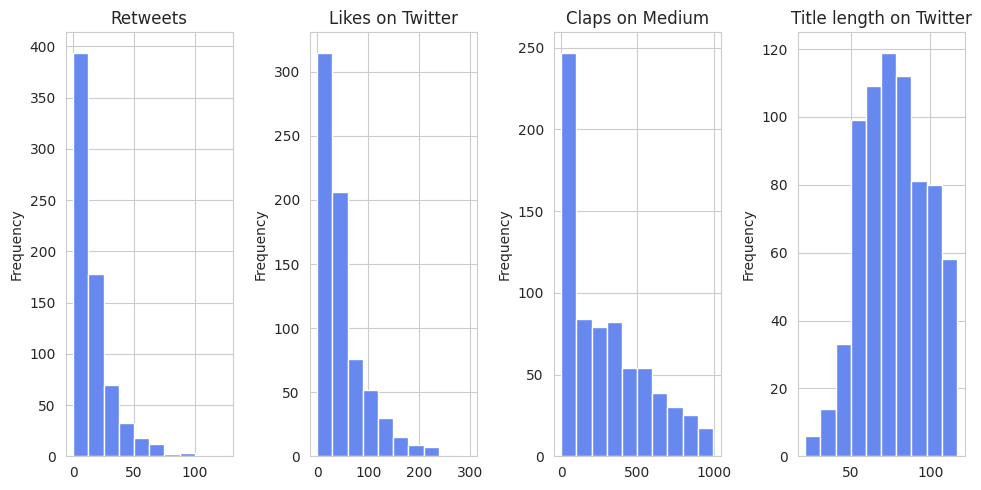

In [ ]:
title_length = 'Title Length'
# set the columns that will show statistic and graph
columns = [{'column_name': 'Retweet', 'column_text': 'Retweets'},
           {'column_name': 'Likes', 'column_text': 'Likes on Twitter'},
           {'column_name': 'Claps', 'column_text': 'Claps on Medium'},
           {'column_name': title_length, 'column_text': 'Title length on Twitter'}]

# plot histogram of columns
plt.figure(figsize=(10, 5))
for el in columns:
    class_name = el['column_name']
    column = title_stat[class_name]
    plt.subplot(1, 4, columns.index(el) + 1)
    plt.tight_layout()
    column.plot.hist(orientation='vertical', cumulative=False, title=el['column_text'])
    if class_name != title_length:
        print('Total {}: {} times'.format(class_name, column.sum()))

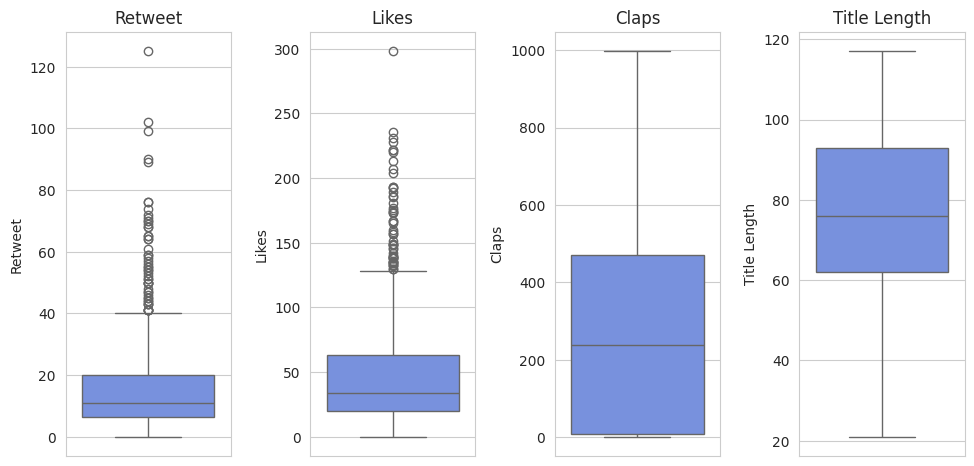

In [ ]:
# plot boxplots
plt.figure(figsize=(10, 5))
for el in columns:
    class_name = el['column_name']
    column = title_stat[class_name]
    plt.subplot(1, 4, columns.index(el) + 1)
    plt.tight_layout()
    plt.title(class_name);
    sns.boxplot(data=column);

From these histograms, together with the overall statistic and the box plots, we can notice that we have a Gaussian distribution for the text length and the average length is around 80 characters. Like, retweet and claps are positive-skewed, i.e. they are concentrated on the left part of the graph, meaning that a small part of the articles will over-perform about readers' interaction and the biggest part of them will generate less interaction.

#### Scatter Matrix

Here we try to find a relationship between the multiple features that we gathered from Twitter and Medium.

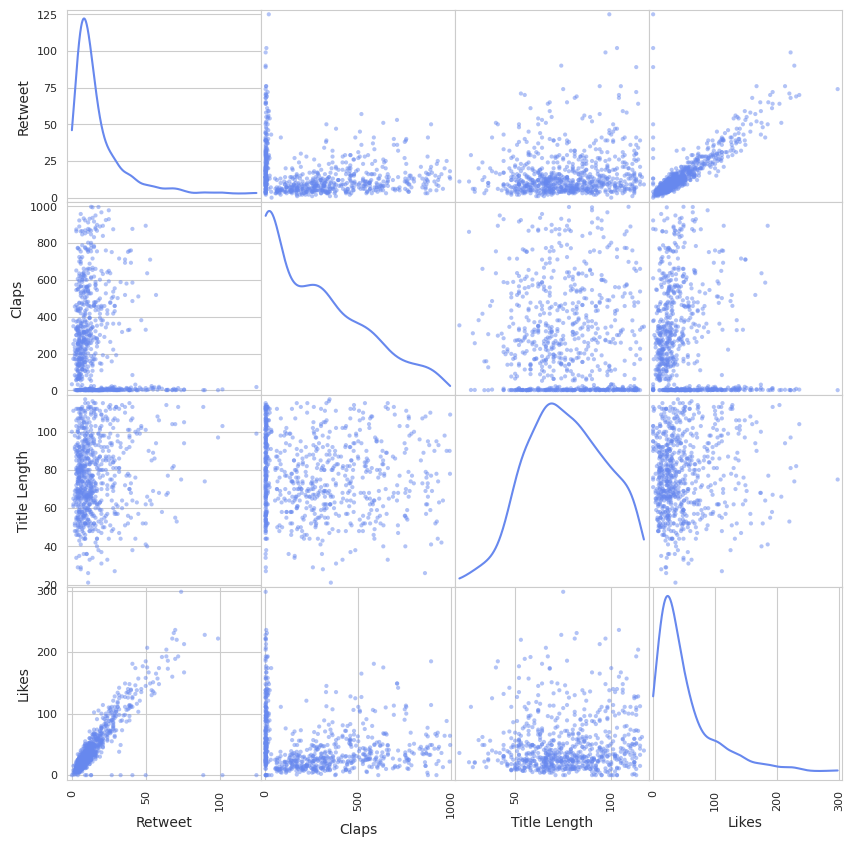

In [ ]:
temp = pd.plotting.scatter_matrix(title_stat, diagonal="kde", figsize=(10, 10))

We can notice for the image about, we can notice a clear relationship between the number of retweets and likes. They are directed connected, it means, the more retweets, the more likes the article will receive and vice versa.

#### Title length that performed better

Here we analyze the relationship between the length of the title with its performance. For this experiment, we just considered the 25% top performers of each feature.

In [ ]:
# function to plot the top performers
PERCENTAGE = 25

In [ ]:
# remove the outlier data ponts. We use the forumla:
# Outlier < Q_1 - 1.5* IQR
# Outlier > Q_3 + 1.5 * IQR
# Where Q_1 and Q_3 are the first and third quartile
# and IQR is the Interquartile Range (IQR = Q_3 - Q_1).
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    non_outliers = (df[column] >= Q1 - 1.5 * IQR) & (df[column] <= Q3 + 1.5 * IQR)
#     non_outliers = df[column] >= 0
    return df.loc[non_outliers]

In [ ]:
# plot relation between the number of retweet/favorite/claps and the title length or words in title
def plot_top_length_performers(col_name, is_grouped):
    plt.figure(figsize=(10, 5))
    for el in columns:
        class_name = el['column_name']
        column = title_stat[class_name]
        if class_name != title_length:
            plt.subplot(1, 3, columns.index(el) + 1)
            plt.tight_layout()
            # remove outliers
            title_stat_top = remove_outliers(title_stat, class_name)
            # get top PERCENTAGE%
            title_stat_top = title_stat_top.sort_values(by=[class_name], ascending=False).head(int(len(title_stat)*(PERCENTAGE/100.00)))
            if (is_grouped):
                temp = title_stat_top.groupby(pd.cut(title_stat_top[col_name], bins=np.arange(0, 140+10, step=10))).count()[class_name]
            else:
                temp = title_stat_top.groupby(title_stat_top[col_name]).count()[class_name]
            temp.plot.bar()
            #sns.despine()
            plt.title('{} frequency'.format(el['column_name']));

/tmp/ipykernel_998/3060047451.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = title_stat_top.groupby(pd.cut(title_stat_top[col_name], bins=np.arange(0, 140+10, step=10))).count()[class_name]
/tmp/ipykernel_998/3060047451.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = title_stat_top.groupby(pd.cut(title_stat_top[col_name], bins=np.arange(0, 140+10, step=10))).count()[class_name]
/tmp/ipykernel_998/3060047451.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or obser

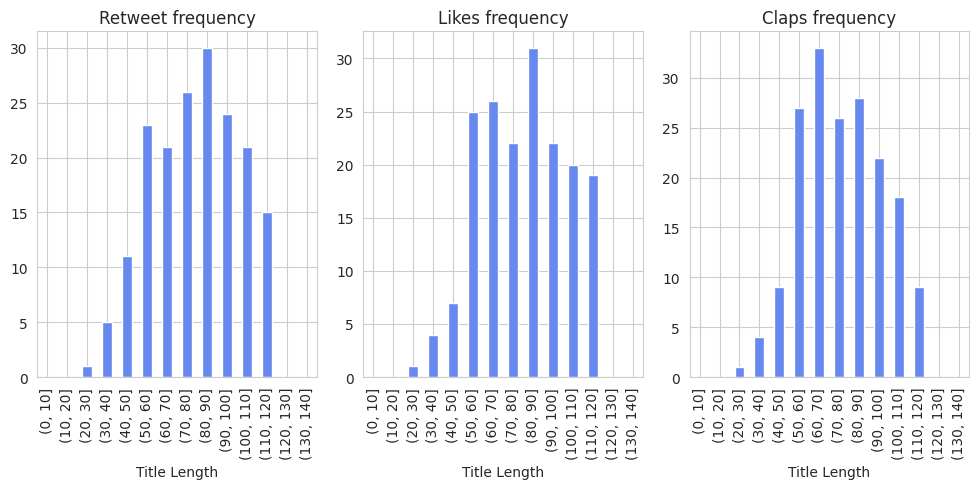

In [ ]:
plot_top_length_performers(title_length, True)

To avoid being biased by outliers, we removed for each feature (likes, retweets and claps) analysis the data points that don't fit the following formulas:

Outlier < Q_1 - 1.5* IQR

Outlier > Q_3 + 1.5 * IQR

Where Q_1 and Q_3 are the first and third quartile and IQR is the Interquartile Range (IQR = Q_3 - Q_1).

We can notice from these graphics that titles longer than 50 and smaller than 120 characters (110 for Medium) perform better than others.

After analyzing the title length and didn't reach any conclusion, we decided to investigate the number of words in the title.

#### Number of words in the title that performed better

From this second experience showed on image bellow, we reached the conclusion that the best number of words in the title is from 9 to 17 words. To optimize the number of retweets and likes something from 9 to 18, and for claps from 7 to 17 words.

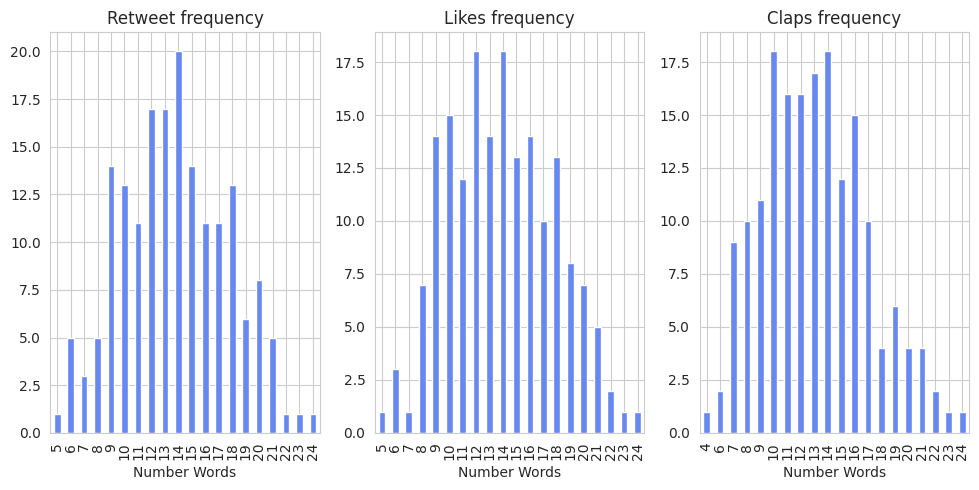

In [ ]:
number_words = 'Number Words'
title_stat[number_words] = title_stat['Title'].str.split().apply(len)
plot_top_length_performers(number_words, False)

#### Categories that performed better

Here we filtered the dataset and just analyzed the top 25% performers for each one of the features. We wanted to have a clear overview of how the categories perform compared between them. The outliers were removed.

In [ ]:
# plot relation between the words used on medium title and the number of retweet/favorite/claps. Just for the top PERCENTAGE% performers
def plot_top_performers(lst_col):
    for el in columns:
        column = title_stat[el['column_name']]
        class_name = el['column_name']
        if class_name != title_length:
            plt.figure(figsize=(10, 5))
            # remove outliers
            title_stat_top = remove_outliers(title_stat, class_name)
            title_stat_top = title_stat_top.sort_values(by=[class_name], ascending=False).head(int(len(title_stat_top)*(PERCENTAGE/100.00)))
            x = pd.DataFrame({
                    col:np.repeat(title_stat_top[col].values, title_stat_top[lst_col].str.len())
                    for col in title_stat_top.columns.difference([lst_col])
                }).assign(**{lst_col:np.concatenate(title_stat_top[lst_col].values)})[title_stat_top.columns.tolist()]
            temp = x.groupby(lst_col).count()[class_name].sort_values(ascending=False).head(20).sort_values(ascending=True)
            temp.plot.barh()
            #sns.despine()
            plt.title('Most used {} on top {}% {}'.format(lst_col, PERCENTAGE, el['column_text']));

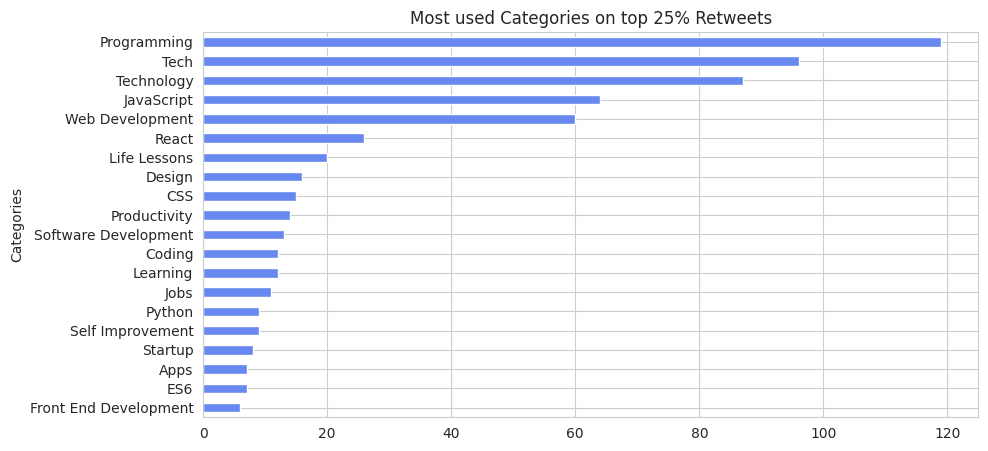

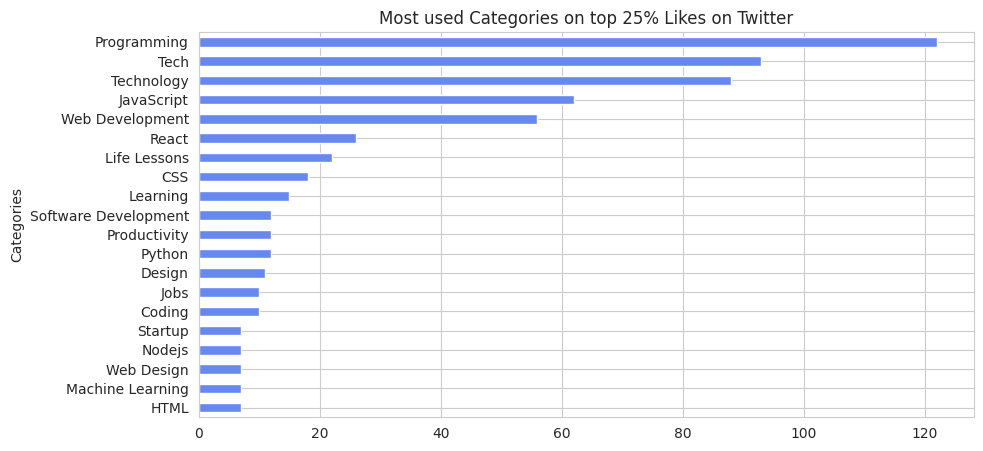

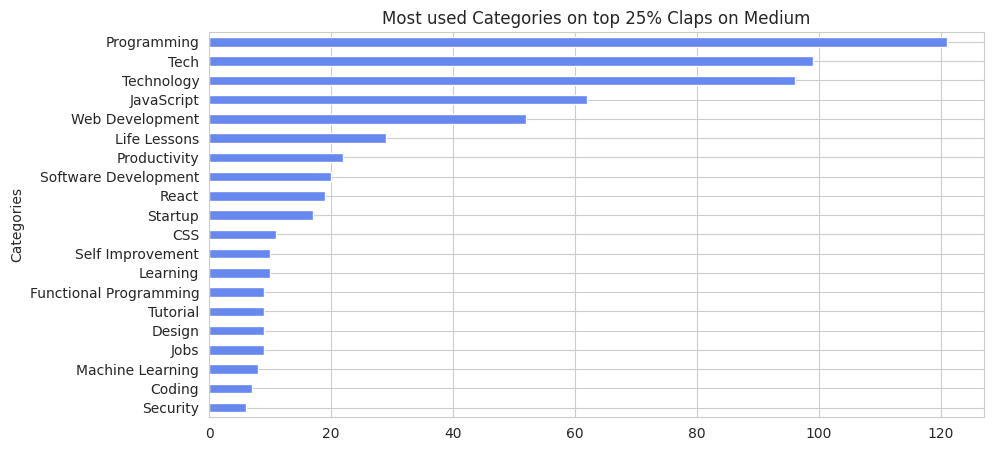

In [ ]:
# plot relation between the tag used on medium (tag) and the number of retweet/favorite/claps
plot_top_performers('Categories')

From this statistic, we notice that articles created with the following categories can increase the number of retweets, likes and claps: "Programming", "Tech", "Technology", "JavaScript" and "Web Development".



#### Words that performed better

We repeated the same strategy of limiting the 25% performers for the words on the title of the article. We wanted to understand if there are words that can boost the interaction from the readers. The outliers were removed.

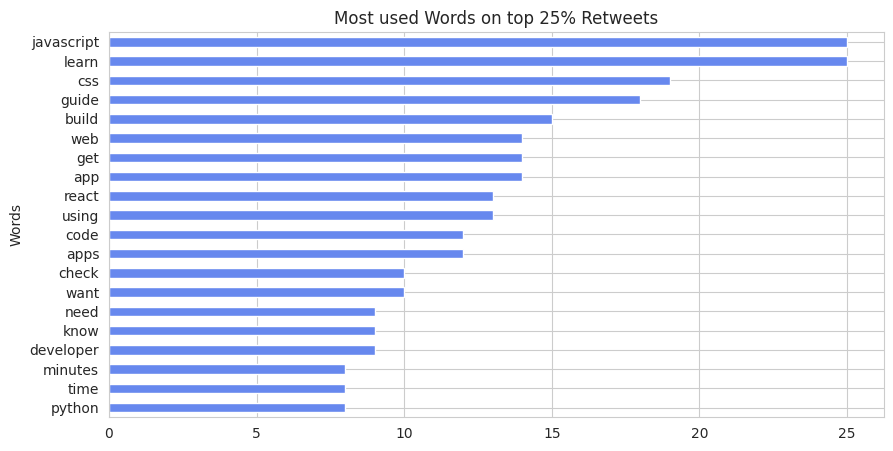

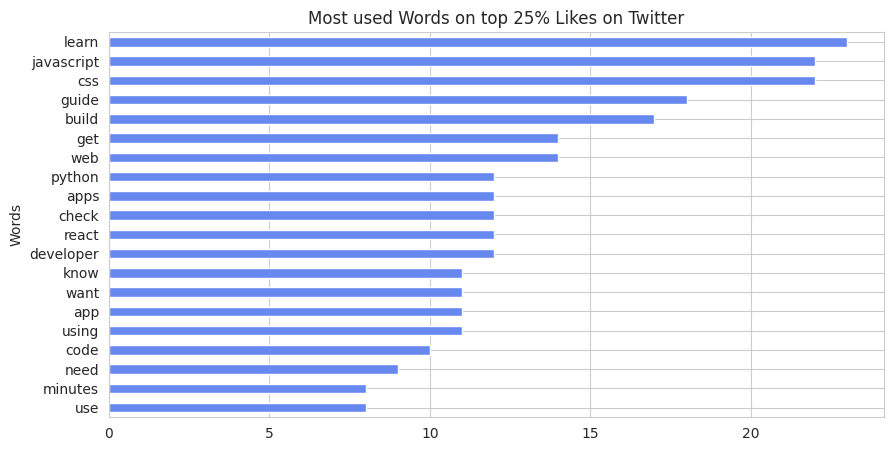

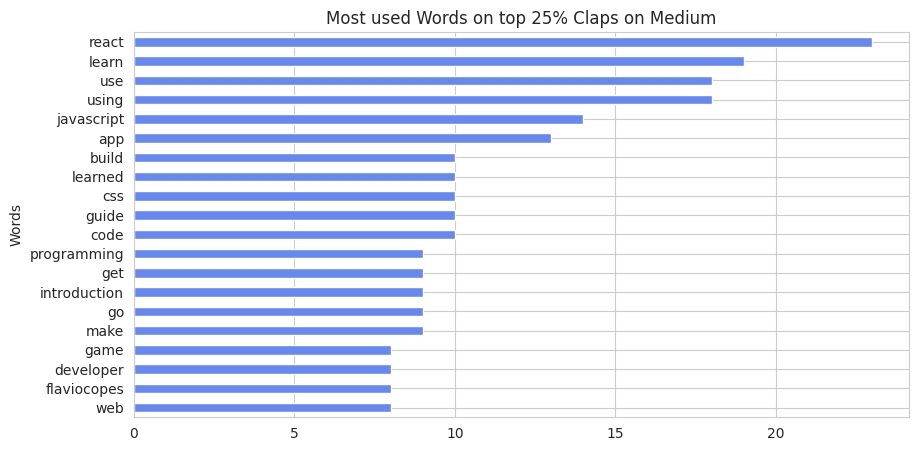

In [ ]:
# create a column containing the words of the title
# remove special characters
temp = title_stat['Title'].str.lower().str.translate(str.maketrans('','','()!@#$:"?,./+')).str.split()
# temp = title_stat['Title'].str.lower().str.split()
# remove common words (it, a, the, ...)
stop=set(stopwords.words('english'))
title_stat['Words'] = temp.apply(lambda x: [item for item in x if item not in stop and not '\\' in item])
# title_stat['Words'] = temp
# print(stop) #uncomment to see removed words
# plot relation between the words used on medium title and the number of retweet/favorite/claps. Just for the top PERCENTAGE% performers
#sns.despine()
plot_top_performers('Words')

In this lexical analysis, we can notice that some words get much more attention on the FreeCodeCamp community than others. If the intention is to make the articles reach further in numbers, talking about JavaScript, React or CSS will increase this change. Using the words "learn" or "guide" to describe will also make the probability higher.

## Data Preprocessing

### Data cleaning


### Assigning classes to the dataset


In [ ]:
def get_category_name(column_name):
    return '{} Category'.format(column_name)

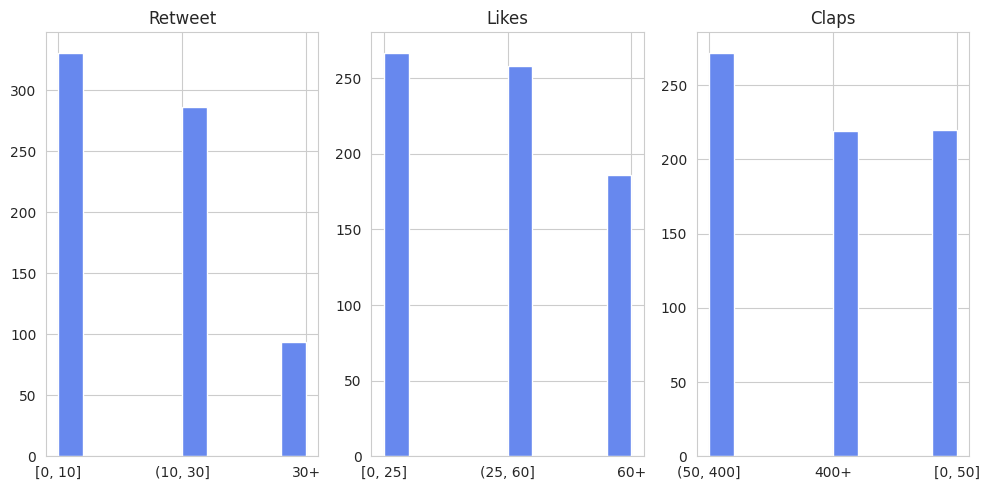

In [ ]:
def get_range(value, ranges):
    for idx,max_value in enumerate(ranges):
        if value <= max_value:
            previous = '({}'.format(ranges[idx-1]) if idx >= 1 else '[0'
            return '{}, {}]'.format(previous, max_value)
    return '{}+'.format(ranges[-1])

# plot histogram of columns
plt.figure(figsize=(10, 5))
for el in columns:
    class_name = el['column_name']
    if class_name != title_length:
        column = title_stat[class_name]
        plt.subplot(1, 3, columns.index(el) + 1)
        plt.tight_layout()
        ranges = {
            'Retweet': [10, 30],
            'Likes': [25, 60],
            'Claps': [50, 400]
        }
        column = [ get_range(a, ranges[class_name]) for a in column ]
        plt.title('{}'.format(class_name))
        pd.DataFrame(column)[0].hist(xrot=0)

        # add classification to dataframe
        title_stat[get_category_name(class_name)] = column

## Implementation

### Training and Testing Data Split




In [ ]:
# clean the title
def clean_title(text):
    # remove twitter users, leave @ for stats reason
    text = text.map(lambda x: re.sub('@[_A-Za-z0-9]+','@',str(x)))
    return text


def split_data(title_stat, class_name, is_remove_outlier, is_clean_text):
            # remove outliers
            if is_remove_outlier:
                title_stat_top = remove_outliers(title_stat, class_name)
            else:
                title_stat_top = title_stat

            # Set the number of testing points
            if is_clean_text:
                X_all = clean_title(title_stat_top['Title'])
            else:
                X_all = title_stat_top['Title']
            y_all = title_stat_top[get_category_name(class_name)]

            # Shuffle and split the dataset into the number of training and testing points above
            X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=ratios[class_name], shuffle=False)

            return {
                'title_stat_top': title_stat_top,
                'X_all': X_all,
                'y_all': y_all,
                'X_train': X_train,
                'X_test': X_test,
                'y_train': y_train,
                'y_test': y_test
            }

In [ ]:
X_all = {}
y_all = {}
X_train = {}
X_test = {}
y_train = {}
y_test = {}

ratios = {
    'Retweet': 0.2,
    'Likes': 0.2,
    'Claps': 0.2
}

for el in columns:
    column = title_stat[el['column_name']]
    class_name = el['column_name']
    if class_name != title_length:
        values = split_data(title_stat, class_name, True, True)
        title_stat_top, X_all[class_name], y_all[class_name], X_train[class_name], X_test[class_name], y_train[class_name], y_test[class_name] = [values[k] for k in ('title_stat_top', 'X_all','y_all', 'X_train', 'X_test', 'y_train', 'y_test')]

        total = title_stat[class_name].count()
        total_no_outliers = title_stat_top[class_name].count()
        print('{}\nTotal: {} items.\nTotal without outliers: {}'.format(class_name, total, total_no_outliers))

        # Show the results of the split
        print("Training set has {} samples".format(X_train[class_name].shape[0]))
        print("Testing set has {} samples\n".format(X_test[class_name].shape[0]))

Retweet
Total: 711 items.
Total without outliers: 658
Training set has 526 samples
Testing set has 132 samples

Likes
Total: 711 items.
Total without outliers: 658
Training set has 526 samples
Testing set has 132 samples

Claps
Total: 711 items.
Total without outliers: 711
Training set has 568 samples
Testing set has 143 samples



### Training and Evaluating Models



In [ ]:
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import FunctionTransformer

# implement bag of words with td-idf
X_train_word_features = {}
test_features = {}

def get_text_length(x):
    return np.array([len(t) for t in x]).reshape(-1, 1)

def get_words_length(x):
    return np.array([len(t.split()) for t in x]).reshape(-1, 1)

def to_array(x):
    return x.toarray()

In [ ]:
# load classifiers
# Initialize the models
# for each classifier was defined (code bellow: Best features) the best parameters for each feature
# if the best parameters calculated for the model is the same as default, i will mark as #DEFAULT
classifiers = [
    # no parameter to test for the model GaussianNB()
    {
        'classifier': GaussianNB(),
        'toarray': True,
        'parameters': {}
    },
    {
        'classifier': LogisticRegression(max_iter=1000), # Increased max_iter
        'toarray': False,
        'parameters': {
            'C': [0.1, 0.5, 1, 2, 10],
            'fit_intercept': [True, False],
            'class_weight': ['balanced', None],
            'solver': ['newton-cg', 'lbfgs', 'liblinear', 'saga'],
            'max_iter': [10, 100, 300] # Adjusted max_iter for GridSearchCV
        }
    },
    {
        'classifier': DecisionTreeClassifier(),
        'toarray': False,
        'parameters': {
            'splitter': ['random', 'best'],
            'max_depth': [1, 5, 10, 20, None],
            'class_weight': ['balanced', None]
        }
    },
    {
        'classifier': SVC(),
        'toarray': True,
        'parameters': {
            'kernel':['linear', 'poly', 'rbf', 'sigmoid'],
            'degree':[1, 2, 3, 4, 5, 6, 7],
            'C':[0.5, 1, 2],
        }
    },
    {
        'classifier': KNeighborsClassifier(),
        'toarray': False,
        'parameters': {
            'n_neighbors': [1, 5, 10, 15, 20, 30],
            'weights': ['distance', 'uniform'],
            'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
            'leaf_size': [10, 30, 50],
        }
    },
    {
        'classifier': MultinomialNB(),
        'toarray': False,
        'parameters': {
                'alpha': [0, 0.5, 1],
                'fit_prior': [True, False]
        }
    },
    {
        'classifier': GradientBoostingClassifier(),
        'toarray': False,
        'parameters': {
            'learning_rate': [0.1, 0.5, 1.0],
            'loss': ['log_loss', 'exponential'],
            'max_depth': [3, 5, 10],
            'min_samples_leaf': [1, 2],
            'min_samples_split': [0.1, 0.5, 1.0],
            'n_estimators': [50, 100],
            'random_state': [0, None],
            'warm_start': [False]
        }
    }
]

In [ ]:
from sklearn.metrics import accuracy_score

def get_score_pipeline(classifier_algo, X_train, y_train):
    classifier = Pipeline([
        ('features', FeatureUnion([
            ('text', Pipeline([
                ('vectorizer', TfidfVectorizer(#TfidfVectorizer#CountVectorizer
                                    stop_words='english',
                                    strip_accents='unicode',
                                    token_pattern=r'\w{1,}',
                                    analyzer='word',
                                    ngram_range=(1, 1),
                                )),
                ('toarray', Pipeline([
                    ('count', FunctionTransformer(to_array, validate=False)),
                ]))
            ])),
            ('length', Pipeline([
                ('count', FunctionTransformer(get_text_length, validate=False)),
            ])),
            ('size', Pipeline([
                ('count', FunctionTransformer(get_words_length, validate=False)),
            ]))
        ])),
        ('clf', OneVsRestClassifier(classifier_algo))])

    cv_score = np.mean(cross_val_score(classifier, X_train, y_train, cv=5, scoring='accuracy'))
    print('\t\tAccuracy score: {}'.format(cv_score))
    return cv_score

def get_score(classifier_algo, X_train, X_test, y_train, y_test, name, is_td_idf=True, is_stop_word=True):
    tokens = tokenize(X_train, X_test, is_td_idf, is_stop_word)
    _X_train = tokens['X_train']
    _X_test = tokens['X_test']

    # fit model
    classifier_algo.fit(_X_train, y_train)
    # predict
    y_pred = classifier_algo.predict(_X_test)
    # measure
    cv_score = accuracy_score(y_test, y_pred)
    print('\t\tAccuracy score ({}): {}'.format(name, cv_score))
    return cv_score

def set_statistic_score(class_name, cv_score, model_name, accuracy, classifier_name):
    # store value, if better than others
    if class_name not in accuracy or accuracy[class_name] < cv_score:
        accuracy[class_name] = cv_score
        classifier_name[class_name] = model_name

def print_complete_stat(X_train, X_test, y_train, y_test):
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_test)
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(X_test, y_test))

def tokenize(X_train, X_test, is_td_idf=True, is_stop_word=True):
    #TfidfVectorizer#CountVectorizer
    if is_td_idf:
        tokenizr = TfidfVectorizer
    else:
        tokenizr = CountVectorizer

    if is_stop_word:
        stop_words='english'
    else:
        stop_words=None

    word_vectorizer = tokenizr(
                        stop_words=stop_words,
                        strip_accents='unicode',
                        token_pattern=r'\w{1,}',
                        analyzer='word',
                        ngram_range=(1, 1))

    word_vectorizer.fit(X_train)
    _X_train = word_vectorizer.transform(X_train)
    _X_train = np.append(_X_train.toarray(), get_text_length(X_train), 1)
    _X_train = np.append(_X_train, get_words_length(X_train), 1)
    _X_test = word_vectorizer.transform(X_test)
    _X_test = np.append(_X_test.toarray(), get_text_length(X_test), 1)
    _X_test = np.append(_X_test, get_words_length(X_test), 1)
    return {
        'X_train': _X_train,
        'X_test': _X_test
    }

def set_score_stat(classifier_algo, class_name, X_train, X_test, y_train, y_test, accuracy, classifier_name, is_default):
    name_type = 'default' if is_default else 'optimized'
    name = '{} ({})'.format(classifier_algo.__class__.__name__, name_type)
    # cv_score = get_score_pipeline(classifier_algo, X_all[class_name], y_all[class_name])
    cv_score = get_score(classifier_algo, X_train, X_test, y_train, y_test, name_type)
    # store value, if better than others
    set_statistic_score(class_name, cv_score, name, accuracy, classifier_name)

In [ ]:
# run the models with the parameters defined and check with has better accuracy
# this method just run the default model for each data set
# Use the method bellow (Looking for: Best features), for a deeper analysis
classifier_name = {}
accuracy = {}

print('Default classifiers')
for clf in classifiers:
    print("==== Classifier: {} ====".format(clf['classifier'].__class__.__name__))
    for el in columns:
        column = title_stat[el['column_name']]
        class_name = el['column_name']
        if class_name != title_length:
            name = 'classifier-{}'.format(class_name)
            # if there is a specific model refined, use it
            classifier_algo = clf[name] if name in clf else clf['classifier']
            print('\t==== {} ===='.format(class_name))

            # calculate score and add to statistic
            set_score_stat(classifier_algo, class_name, X_train[class_name], X_test[class_name], y_train[class_name], y_test[class_name], accuracy, classifier_name, True)

            # print_complete_stat(X_train[class_name], X_test[class_name], y_train[class_name], y_test[class_name])

print('Best scores:')
print(accuracy)
print(classifier_name)

Default classifiers
==== Classifier: GaussianNB ====
	==== Retweet ====
		Accuracy score (default): 0.49242424242424243
	==== Likes ====
		Accuracy score (default): 0.4621212121212121
	==== Claps ====
		Accuracy score (default): 0.4125874125874126
==== Classifier: LogisticRegression ====
	==== Retweet ====
		Accuracy score (default): 0.5833333333333334
	==== Likes ====
		Accuracy score (default): 0.45454545454545453
	==== Claps ====
		Accuracy score (default): 0.48951048951048953
==== Classifier: DecisionTreeClassifier ====
	==== Retweet ====
		Accuracy score (default): 0.5
	==== Likes ====
		Accuracy score (default): 0.48484848484848486
	==== Claps ====
		Accuracy score (default): 0.3706293706293706
==== Classifier: SVC ====
	==== Retweet ====
		Accuracy score (default): 0.5454545454545454
	==== Likes ====
		Accuracy score (default): 0.49242424242424243
	==== Claps ====
		Accuracy score (default): 0.4125874125874126
==== Classifier: KNeighborsClassifier ====
	==== Retweet ====
		Accur

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from scipy.sparse import hstack
from tqdm.notebook import tqdm
from sklearn.preprocessing import LabelEncoder

accuracy = {}
classifier_name = {}
models_winners = {}
import warnings; warnings.simplefilter('ignore')
for classifier in tqdm(classifiers):
    for el in tqdm(columns):
        # el = {'column_name': 'Retweet', 'column_text': 'Retweets'}
        # el = {'column_name': 'Favorites', 'column_text': 'Favorites on Twitter'}
        # el = {'column_name': 'Claps', 'column_text': 'Claps on Medium'}
        column = title_stat[el['column_name']]
        class_name = el['column_name']
        clf = classifier['classifier']
        parameters = classifier['parameters']
        print("==== Classifier: {} ====".format(clf.__class__.__name__))
        if class_name != title_length:
            print('\t==== {} ===='.format(class_name))

            # Initialize LabelEncoder for current class_name
            le = LabelEncoder()
            # Fit on combined unique y values to ensure all categories are covered
            y_combined_labels = pd.concat([y_train[class_name], y_test[class_name]]).unique()
            le.fit(y_combined_labels)

            y_train_encoded = le.transform(y_train[class_name])
            y_test_encoded = le.transform(y_test[class_name])

            # calculate score and add to statistic for the default classifier
            # Use the encoded y_train and y_test
            set_score_stat(clf, class_name, # Use 'clf' for the default run
                            X_train[class_name], X_test[class_name],
                            y_train_encoded, y_test_encoded, # Pass encoded targets
                            accuracy, classifier_name, True)

            # Grid search on the classifier using the accuracy_score as the scoring method
            grid_obj = GridSearchCV(clf, param_grid = parameters, scoring=make_scorer(accuracy_score),cv=3,n_jobs=-1)

            tokens = tokenize(X_train[class_name], X_test[class_name])
            _X_train = tokens['X_train']

            # Fit the grid search object to the training data and find the optimal parameters
            # Use encoded y_train
            grid_obj = grid_obj.fit(_X_train, y_train_encoded)

            # Get the estimator
            print('Model best estimator: {}'.format(grid_obj.best_estimator_))

            models_winners[class_name] = grid_obj.best_estimator_

            # calculate score and add to statistic for the optimized classifier
            classifier_algo = grid_obj.best_estimator_
            # Use the encoded y_train and y_test
            set_score_stat(classifier_algo, class_name,
                            X_train[class_name], X_test[class_name],
                            y_train_encoded, y_test_encoded, # Pass encoded targets
                            accuracy, classifier_name, False)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

==== Classifier: GaussianNB ====
	==== Retweet ====
		Accuracy score (default): 0.49242424242424243
Model best estimator: GaussianNB()
		Accuracy score (optimized): 0.49242424242424243
==== Classifier: GaussianNB ====
	==== Likes ====
		Accuracy score (default): 0.4621212121212121
Model best estimator: GaussianNB()
		Accuracy score (optimized): 0.4621212121212121
==== Classifier: GaussianNB ====
	==== Claps ====
		Accuracy score (default): 0.4125874125874126
Model best estimator: GaussianNB()
		Accuracy score (optimized): 0.4125874125874126
==== Classifier: GaussianNB ====


  0%|          | 0/4 [00:00<?, ?it/s]

==== Classifier: LogisticRegression ====
	==== Retweet ====
		Accuracy score (default): 0.5833333333333334
Model best estimator: LogisticRegression(C=10, max_iter=300)
		Accuracy score (optimized): 0.5227272727272727
==== Classifier: LogisticRegression ====
	==== Likes ====
		Accuracy score (default): 0.45454545454545453
Model best estimator: LogisticRegression(C=2, class_weight='balanced', fit_intercept=False,
                   max_iter=10, solver='liblinear')
		Accuracy score (optimized): 0.48484848484848486
==== Classifier: LogisticRegression ====
	==== Claps ====
		Accuracy score (default): 0.48951048951048953
Model best estimator: LogisticRegression(C=2, max_iter=10, solver='newton-cg')
		Accuracy score (optimized): 0.5034965034965035
==== Classifier: LogisticRegression ====


...

==== Classifier: KNeighborsClassifier ====
	==== Retweet ====
		Accuracy score (default): 0.5
Model best estimator: KNeighborsClassifier(algorithm='ball_tree', n_neighbors=30, weights='distance')
		Accuracy score (optimized): 0.5378787878787878
==== Classifier: KNeighborsClassifier ====
	==== Likes ====
		Accuracy score (default): 0.3939393939393939
Model best estimator: KNeighborsClassifier(algorithm='ball_tree', leaf_size=50, n_neighbors=10)
		Accuracy score (optimized): 0.3939393939393939
==== Classifier: KNeighborsClassifier ====
	==== Claps ====
		Accuracy score (default): 0.3706293706293706
Model best estimator: KNeighborsClassifier(algorithm='kd_tree', n_neighbors=15)
		Accuracy score (optimized): 0.40559440559440557
==== Classifier: KNeighborsClassifier ====


  0%|          | 0/4 [00:00<?, ?it/s]

==== Classifier: MultinomialNB ====
	==== Retweet ====
		Accuracy score (default): 0.6060606060606061
Model best estimator: MultinomialNB(alpha=1)
		Accuracy score (optimized): 0.6060606060606061
==== Classifier: MultinomialNB ====
	==== Likes ====
		Accuracy score (default): 0.4090909090909091
Model best estimator: MultinomialNB(alpha=0.5)
		Accuracy score (optimized): 0.45454545454545453
==== Classifier: MultinomialNB ====
	==== Claps ====
		Accuracy score (default): 0.3146853146853147
Model best estimator: MultinomialNB(alpha=0.5)
		Accuracy score (optimized): 0.42657342657342656
==== Classifier: MultinomialNB ====


  0%|          | 0/4 [00:00<?, ?it/s]

==== Classifier: GradientBoostingClassifier ====
	==== Retweet ====
		Accuracy score (default): 0.5606060606060606
Model best estimator: GradientBoostingClassifier(max_depth=5, min_samples_split=0.1, n_estimators=50)
		Accuracy score (optimized): 0.5757575757575758
==== Classifier: GradientBoostingClassifier ====
	==== Likes ====
		Accuracy score (default): 0.5151515151515151
Model best estimator: GradientBoostingClassifier(learning_rate=0.5, min_samples_leaf=2,
                           min_samples_split=0.1, n_estimators=50)
		Accuracy score (optimized): 0.5
==== Classifier: GradientBoostingClassifier ====
	==== Claps ====
		Accuracy score (default): 0.42657342657342656
Model best estimator: GradientBoostingClassifier(max_depth=5, min_samples_split=0.5, n_estimators=50,
                           random_state=0)
		Accuracy score (optimized): 0.4405594405594406
==== Classifier: GradientBoostingClassifier ====


## Refinement



In [ ]:
# Plot for the winners the hit and lost points
models_winners = {
    'Retweet': MultinomialNB(alpha=1, class_prior=None, fit_prior=True),
    'Likes': LogisticRegression(C=10, class_weight=None, dual=False, fit_intercept=False, intercept_scaling=1, max_iter=100, multi_class='ovr', n_jobs=1, penalty='l2', random_state=None, solver='lbfgs', tol=0.0001, verbose=0, warm_start=False),
    'Claps': LogisticRegression(C=2, class_weight=None, dual=False, fit_intercept=True, intercept_scaling=1, max_iter=10, multi_class='ovr', n_jobs=1, penalty='l2', random_state=None, solver='liblinear', tol=0.0001, verbose=0, warm_start=False)
}

info = {}
for el in columns:
    column = title_stat[el['column_name']]
    class_name = el['column_name']
    acc = []
    if class_name != title_length:
        print('\t==== {} ===='.format(class_name))

        # how evolved the refinement of the solution
        configurations = [
            {'is_remove_outlier': False, 'is_clean_text': False, 'is_td_idf': False, 'is_stop_word':  False, 'title': 'Benchmark', 'tag': 'benchmark', 'model_winner': False},
            {'is_remove_outlier': True, 'is_clean_text': False, 'is_td_idf': False, 'is_stop_word':  False, 'title': 'No outlier', 'tag': 't1', 'model_winner': False},
            {'is_remove_outlier': True, 'is_clean_text': True, 'is_td_idf': False, 'is_stop_word':  False, 'title': 'No outlier + clean words', 'tag': 't2', 'model_winner': False},
            {'is_remove_outlier': True, 'is_clean_text': True, 'is_td_idf': True, 'is_stop_word':  False, 'title': 'No outlier + clean words + td-idf', 'tag': 't3', 'model_winner': False},
            {'is_remove_outlier': True, 'is_clean_text': True, 'is_td_idf': True, 'is_stop_word':  True, 'title': 'No outlier + clean words + td-idf + stopwords', 'tag': 't4', 'model_winner': False},
            {'is_remove_outlier': True, 'is_clean_text': True, 'is_td_idf': True, 'is_stop_word':  True, 'title': 'Winner model = No outliers + clean words + td-idf + stopwords + parameter tuned', 'tag': 'winner', 'model_winner': True},
        ]

        for c in configurations:
            # run for the benchmark
            print(c['title'])
            classifier_algo = models_winners[class_name] if c['model_winner'] else LogisticRegression()
            values = split_data(title_stat, class_name, c['is_remove_outlier'], c['is_clean_text'])
            title_stat_top2, X2_all, y2_all, X2_train, X2_test, y2_train, y2_test = [values[k] for k in ('title_stat_top', 'X_all','y_all', 'X_train', 'X_test', 'y_train', 'y_test')]
            acc.append(get_score(classifier_algo, X2_train, X2_test, y2_train, y2_test, c['tag'], c['is_td_idf'], c['is_stop_word']))

        info[class_name] = pd.DataFrame({
            'evolution': ['benchmark', 't1', 't2', 't3', 't4', 'winner'],
            'accuracy': list(map(lambda x: 100*x, acc))
        })


	==== Retweet ====
Benchmark
		Accuracy score (benchmark): 0.5524475524475524
No outlier
		Accuracy score (t1): 0.6136363636363636
No outlier + clean words
		Accuracy score (t2): 0.5833333333333334
No outlier + clean words + td-idf
		Accuracy score (t3): 0.6136363636363636
No outlier + clean words + td-idf + stopwords
		Accuracy score (t4): 0.5909090909090909
Winner model = No outliers + clean words + td-idf + stopwords + parameter tuned
		Accuracy score (winner): 0.6060606060606061
	==== Likes ====
Benchmark
		Accuracy score (benchmark): 0.48951048951048953
No outlier
		Accuracy score (t1): 0.5227272727272727
No outlier + clean words
		Accuracy score (t2): 0.5
No outlier + clean words + td-idf
		Accuracy score (t3): 0.44696969696969696
No outlier + clean words + td-idf + stopwords
		Accuracy score (t4): 0.4621212121212121
Winner model = No outliers + clean words + td-idf + stopwords + parameter tuned
		Accuracy score (winner): 0.5681818181818182
	==== Claps ====
Benchmark
		Accuracy s

In [ ]:
import joblib
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# 1. Clean the text using the function you defined earlier
X_text = clean_title(title_stat['Title'])

# 2. Get your target labels
y_retweet = title_stat['Retweet Category']
y_likes = title_stat['Likes Category']
y_claps = title_stat['Claps Category']

# 3. Fit the TF-IDF Vectorizer on the full dataset
final_vectorizer = TfidfVectorizer(stop_words='english', strip_accents='unicode', token_pattern=r'\w{1,}', analyzer='word', ngram_range=(1, 1))
X_tfidf = final_vectorizer.fit_transform(X_text).toarray()

# 4. Add the 'Title Length' and 'Number Words' features
text_lengths = np.array([len(t) for t in X_text]).reshape(-1, 1)
word_counts = np.array([len(t.split()) for t in X_text]).reshape(-1, 1)

# Combine into one final feature matrix
X_final = np.append(X_tfidf, text_lengths, axis=1)
X_final = np.append(X_final, word_counts, axis=1)

# 5. Initialize your winning models
retweet_model = MultinomialNB(alpha=1, fit_prior=True)
likes_model = LogisticRegression(C=10, fit_intercept=False, solver='lbfgs', max_iter=100)
claps_model = LogisticRegression(C=2, fit_intercept=True, solver='liblinear', max_iter=10)

# 6. FIT (TRAIN) THE MODELS
print("Training models...")
retweet_model.fit(X_final, y_retweet)
likes_model.fit(X_final, y_likes)
claps_model.fit(X_final, y_claps)
print("Models trained successfully!")

# 7. Save the fitted models and the vectorizer
joblib.dump(retweet_model, 'retweet_model.pkl')
joblib.dump(likes_model, 'likes_model.pkl')
joblib.dump(claps_model, 'claps_model.pkl')
joblib.dump(final_vectorizer, 'vectorizer.pkl')

print("Files saved! Please download them and replace the old ones.")

Training models...
Models trained successfully!
Files saved! Please download them and replace the old ones.


# Results

## Model Evaluation and Validation

The tables bellow describe the accuracy values we reached with the proposed model. The final accuracy for each of the features are: likes is 55.3%, retweets is 60.6% and claps is 49%.

Here is the updated output including the benchmark scores:

**Accuracy Retweet (%)**

| ID | Model Name | Default | Tuned |
| :-: | :------------------------------------------: | :--------------------: | :--------------: |
| 0 | Benchmark | 55.24 | -- |
| 1 | GaussianNB | 49.24 | 49.24 |
| 2 | LogisticRegression | 58.33 | 52.27 |
| 3 | DecisionTreeClassifier | 53.03 | 56.82 |
| 4 | SVC | 54.55 | 58.33 |
| 5 | KNeighborsClassifier | 50.00 | 53.79 |
| 6 | **MultinomialNB** | **61.36** | 60.61 |
| 7 | GradientBoostingClassifier | 56.06 | 57.58 |

**Accuracy Likes (%)**

| ID | Model Name | Default | Tuned |
| :-: | :------------------------------------------: | :--------------------: | :--------------: |
| 0 | Benchmark | 48.95 | -- |
| 1 | GaussianNB | 46.21 | 46.21 |
| 2 | LogisticRegression | 45.45 | 48.48 |
| 3 | DecisionTreeClassifier | 45.45 | 49.24 |
| 4 | SVC | 49.24 | 51.52 |
| 5 | KNeighborsClassifier | 39.39 | 39.39 |
| 6 | MultinomialNB | 40.91 | 45.45 |
| 7 | **GradientBoostingClassifier** |52.27 | **56.82** |

**Accuracy Claps (%)**

| ID | Model Name | Default | Tuned |
| :-: | :------------------------------------------: | :--------------------: | :--------------: |
| 0 | Benchmark | 46.15 | -- |
| 1 | GaussianNB | 41.26 | 41.26 |
| 2 | **LogisticRegression** | 48.95 | **50.35** |
| 3 | DecisionTreeClassifier | 32.17 | 35.66 |
| 4 | SVC | 41.26 | 48.95 |
| 5 | KNeighborsClassifier | 37.06 | 40.56 |
| 6 | MultinomialNB | 31.47 | 42.66 |
| 7 | GradientBoostingClassifier | 42.66 | 44.06 |

The parameters that we obtained by the grid search of the models and features are explained in the tables bellow.

Of course, here is the information formatted as you requested.

**Tuned Parameters Retweet (%)**

| ID | Parameters |
| :-: | :------------------------------------------: |
| 1 | GaussianNB() |
| 2 | LogisticRegression(C=10, max_iter=300) |
| 3 | DecisionTreeClassifier(max_depth=20, splitter='random') |
| 4 | SVC(C=1, degree=1, kernel='linear') |
| 5 | KNeighborsClassifier(algorithm='ball_tree', n_neighbors=30, weights='distance') |
| 6 | MultinomialNB(alpha=1) |
| 7 | GradientBoostingClassifier(max_depth=5, min_samples_split=0.1, n_estimators=50) |

**Tuned Parameters Likes (%)**

| ID | Parameters |
| :-: | :------------------------------------------: |
| 1 | GaussianNB() |
| 2 | LogisticRegression(C=2, class_weight='balanced', fit_intercept=False, max_iter=10, solver='liblinear') |
| 3 | DecisionTreeClassifier() |
| 4 | SVC(C=1, degree=1, kernel='linear') |
| 5 | KNeighborsClassifier(algorithm='ball_tree', leaf_size=50, n_neighbors=10) |
| 6 | MultinomialNB(alpha=0.5) |
| 7 | GradientBoostingClassifier(learning_rate=0.5, min_samples_leaf=2, min_samples_split=0.1, n_estimators=50) |

**Tuned Parameters Claps (%)**

| ID | Parameters |
| :-: | :------------------------------------------: |
| 1 | GaussianNB() |
| 2 | LogisticRegression(C=2, max_iter=10, solver='newton-cg') |
| 3 | DecisionTreeClassifier(max_depth=20, splitter='random') |
| 4 | SVC(C=2, degree=1, kernel='linear') |
| 5 | KNeighborsClassifier(algorithm='kd_tree', n_neighbors=15) |
| 6 | MultinomialNB(alpha=0.5) |
| 7 | GradientBoostingClassifier(max_depth=5, min_samples_split=0.5, n_estimators=50, random_state=0) |

## Justification

The benchmark used on this project was Logistic Regression model, with ID 0 and named Benchmark on the tables Accuracy Likes, Accuracy Retweets and Accuracy Claps above.

In all the scenarios our models predicted better than the benchmark, for this reason, we can assume the decisions made on the step Metodology - Refinement led us to a better model.


# Conclusion

## Free-Form Visualization

The image bellow shows the evolution of the development of this project. We started with the benchmark. From there we started adding and testing features and treating the dataset. The steps are described by the table \ref{table:accuracy-evolution}.

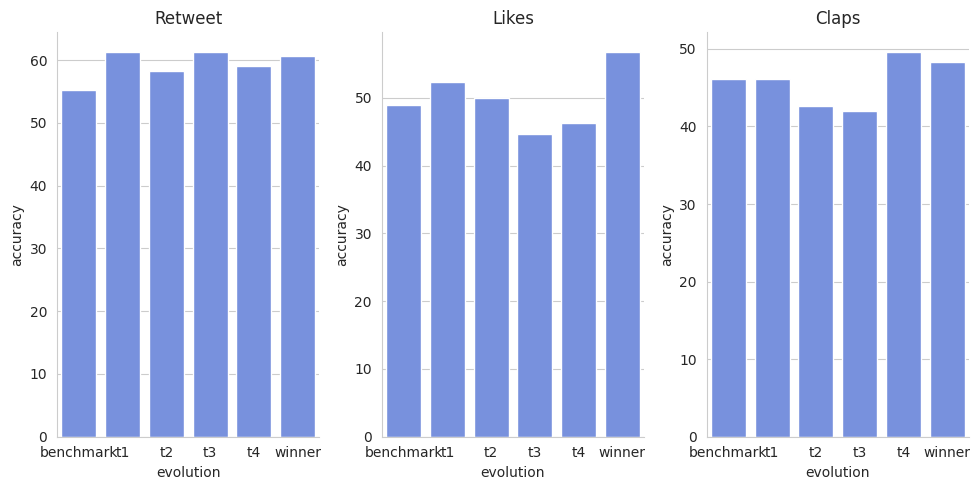

In [ ]:
plt.figure(figsize=(10, 5))
for el in columns:
    class_name = el['column_name']
    if class_name != title_length:
        plt.subplot(1, 3, columns.index(el) + 1)
        plt.tight_layout()
        plt.title(class_name);
        values = info[class_name]
        sns.barplot(x=values['evolution'], y=values['accuracy'])
        sns.despine()

During the evolution of the metrics, some variables deprecated the accuracy value, but in further steps, it made it grow. The evolution happened in the following steps:

* Benchmark
* t1: Removed outliers
* t2: t1 + Cleaned the words
* t3: t2 + Added TF-IDF
* t4: t3 + Used stopwords
* Winner: t4 + Parameters from the model tuned

## Reflection

In this project, we developed classifiers to understand how many times an article will receive interaction like retweets and likes (both on Twitter) and claps (on Medium). We also presented a list of words that have a high change to impact positively with the readers, when used on the title or the article. We classified and extracted information about the Categories used on Medium that are commonly presented on our top performers. The number of words and length of the title were also discussed and presented an optimal number to increase the success numbers.

Besides the mathematical analysis used to extract important characteristics of the dataset, we also developed and trained models to predict the how an article would perform. To achieve this machine learning project, some features and characteristics were used:

* Bag of words to tokenize the words of the title
* Term Frequency, Inverse Document Frequency (TF-IDF) to translate the frequency of words in the dataset
* Clean the dataset and each title before training the model (remove Twiter users and invalid characters)
* Grid search to search for the best model parameters
* Remove outliers before processing the data
* Test the dataset to discover a good relation between train and test data points
* Test and split the number of like, retweet and claps in ranges
* Use stopwords to remove common terms of the language

Following these steps listed here, this methodology and framework can be used to classify any kind of article and subjects that are created on Medium and shared on Twitter. This solution is not limited by the context either the subject of the articles and can be easily reproduced to other datasets.

The hard part of the project was to reach a higher accuracy than the one found with simple models, it was necessary multiple reiterations and several modifications on the initial assumption. Reaching the 61%, 55% and 49% is not the ideal solution, but it can clearly lead to the creation of a good title.

## Improvement

For future work we can think about some additional improvements: Adding more features to the original dataset making possible to relate more information to the success of the article. For example, we can correlate the words of the title, with trendy words of the month; Bring more data points to train our model, would also increase the accuracy of the solution; and try to use the position of the word on the title to classify its importance.